# 03 — K-means Clustering Recommender (Xizhi)
Unsupervised approach: cluster (user, song) joint feature vectors,
then recommend popular songs from the matched cluster.

In [6]:
!git clone https://github.com/simongydvandy/Song-Rec-Project-for-CS-3262.git
%cd Song-Rec-Project-for-CS-3262/notebooks
%cd /content/Song-Rec-Project-for-CS-3262

Cloning into 'Song-Rec-Project-for-CS-3262'...
remote: Enumerating objects: 29, done.
remote: Counting objects: 100% (29/29), done.
remote: Compressing objects: 100% (24/24), done.
remote: Total 29 (delta 6), reused 23 (delta 4), pack-reused 0 (from 0)
Receiving objects: 100% (29/29), 465.58 KiB | 13.30 MiB/s, done.
Resolving deltas: 100% (6/6), done.
/content/Song-Rec-Project-for-CS-3262/notebooks/Song-Rec-Project-for-CS-3262/notebooks
/content/Song-Rec-Project-for-CS-3262


In [8]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path('./src')))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler

from preprocess import load_and_clean, build_joint_features, build_user_features, build_song_features
from kmeans_recommender import KMeansRecommender, elbow_analysis, plot_elbow
from evaluate import kmeans_genre_accuracy

sns.set_theme(style='whitegrid')
df = load_and_clean()
joint = build_joint_features(df)
user_feats = build_user_features(df)
song_feats = build_song_features(df)
print('Data shape:', df.shape, '| Joint features:', joint.shape)

Data shape: (170, 12) | Joint features: (170, 34)


In [9]:
import pathlib

src_path = pathlib.Path('..') / 'src'

if src_path.exists() and src_path.is_dir():
    print(f"The 'src' directory exists at: {src_path.resolve()}")
else:
    print(f"Error: The 'src' directory does not exist or is not a directory at: {src_path.resolve()}")
    print("Please ensure the 'src' folder is located one directory level up from this notebook.")

Error: The 'src' directory does not exist or is not a directory at: /content/src
Please ensure the 'src' folder is located one directory level up from this notebook.


## Step 1: Scale features

In [10]:
scaler = StandardScaler()
scaled = scaler.fit_transform(joint.values)
print('Scaled matrix shape:', scaled.shape)

Scaled matrix shape: (170, 34)


## Step 2: Elbow method + Silhouette analysis to choose K

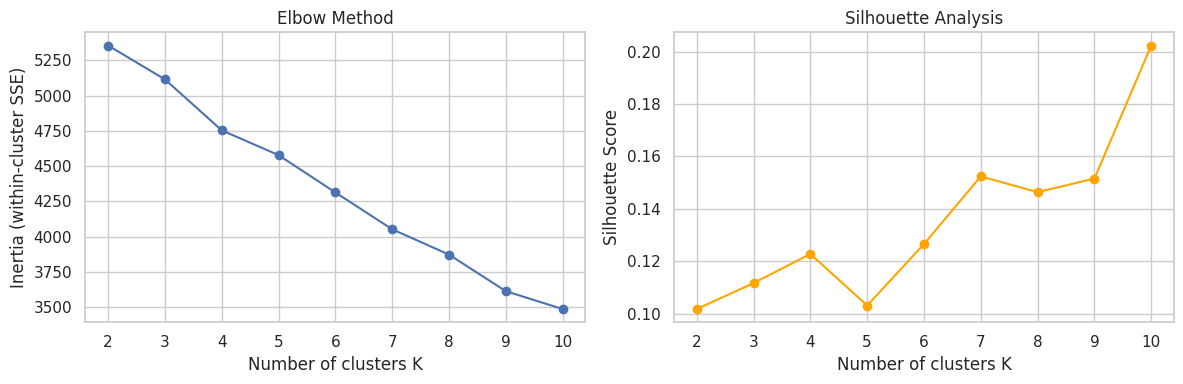

K  | Inertia   | Silhouette
 2 |   5354.21 | 0.1017
 3 |   5114.37 | 0.1116
 4 |   4753.56 | 0.1228
 5 |   4578.02 | 0.1031
 6 |   4313.77 | 0.1266
 7 |   4052.85 | 0.1524
 8 |   3873.52 | 0.1464
 9 |   3614.63 | 0.1516
10 |   3487.84 | 0.2023


In [16]:
k_range = range(2, 11)
inertias, sil_scores = elbow_analysis(scaled, k_range=k_range)

fig = plot_elbow(k_range, inertias, sil_scores)
plt.show()

print('K  | Inertia   | Silhouette')
for k, ine, sil in zip(k_range, inertias, sil_scores):
    print(f'{k:2d} | {ine:9.2f} | {sil:.4f}')

## Step 3: Fit final model with chosen K

In [18]:
# Choose K with highest silhouette score
best_k = list(k_range)[int(np.argmax(sil_scores))]
print(f'Chosen K = {best_k} (silhouette = {max(sil_scores):.4f})')

model = KMeansRecommender(n_clusters=best_k)
model.fit(df, joint)
print('Cluster distribution:')
print(df['user_id'].to_frame().assign(cluster=model._labels)['cluster'].value_counts().sort_index())

Chosen K = 10 (silhouette = 0.2023)
Cluster distribution:
cluster
0    22
1    59
2    17
3     1
4     7
5     2
6    44
7     2
8    10
9     6
Name: count, dtype: int64


## Step 4: Cluster genre profiles

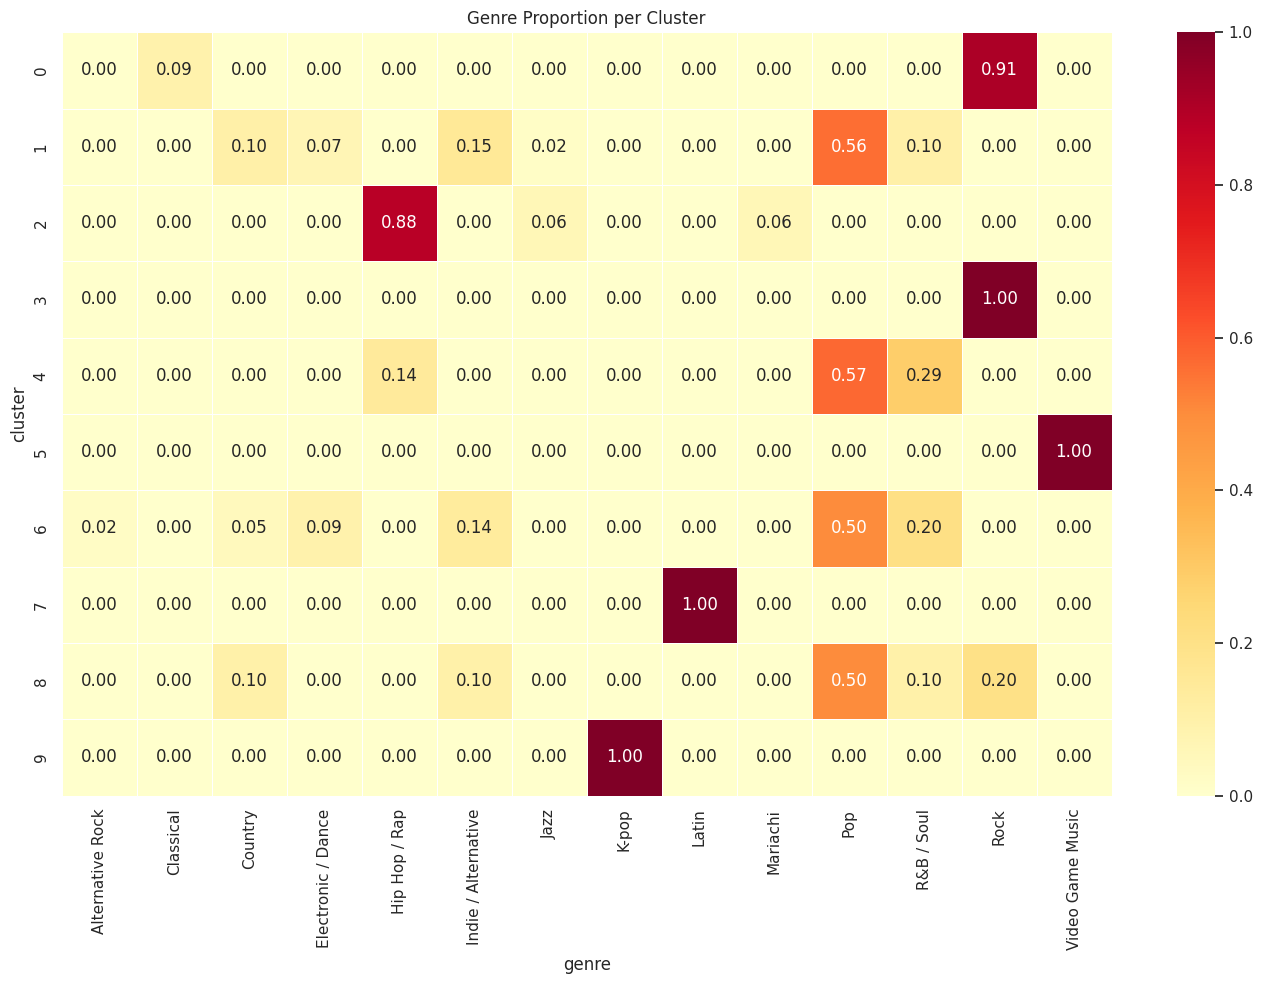

In [19]:
profile = model.cluster_genre_profile()

# Pivot for heatmap
pivot = profile.pivot_table(index='cluster', columns='genre', values='proportion', fill_value=0)
fig, ax = plt.subplots(figsize=(14, max(3, best_k)))
sns.heatmap(pivot, annot=True, fmt='.2f', cmap='YlOrRd', linewidths=0.5, ax=ax)
ax.set_title('Genre Proportion per Cluster')
plt.tight_layout()
plt.show()

## Step 5: Demographic profile per cluster

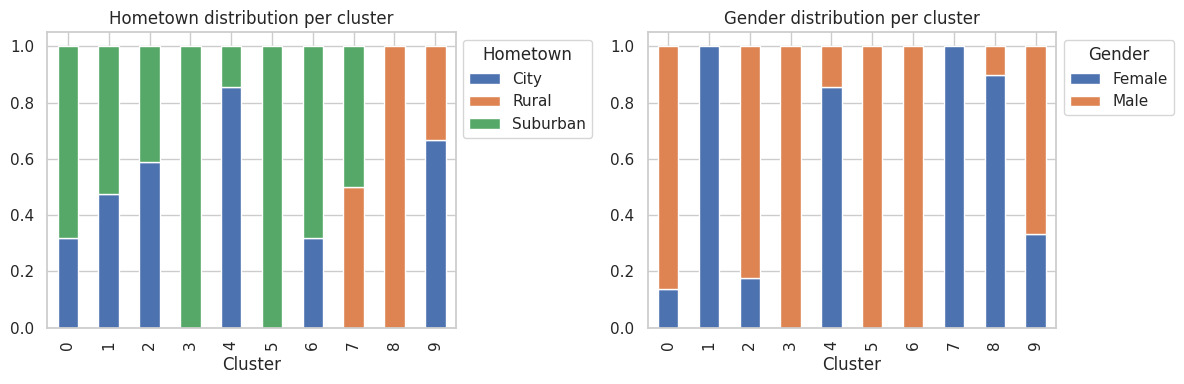

In [20]:
df_with_cluster = model._df.copy()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
pd.crosstab(df_with_cluster['cluster'], df_with_cluster['hometown'], normalize='index').plot(
    kind='bar', ax=axes[0], stacked=True
)
axes[0].set_title('Hometown distribution per cluster')
axes[0].set_xlabel('Cluster')
axes[0].legend(title='Hometown', bbox_to_anchor=(1, 1))

pd.crosstab(df_with_cluster['cluster'], df_with_cluster['gender'], normalize='index').plot(
    kind='bar', ax=axes[1], stacked=True
)
axes[1].set_title('Gender distribution per cluster')
axes[1].set_xlabel('Cluster')
axes[1].legend(title='Gender', bbox_to_anchor=(1, 1))

plt.tight_layout()
plt.show()

## Step 6: Sample recommendations

In [21]:
# Pick the first user and get recommendations
sample_user = df['user_id'].value_counts().index[0]
user_row_idx = df[df['user_id'] == sample_user].index[0]

demo_vec = user_feats.iloc[user_row_idx].values
song_vec = np.zeros(song_feats.shape[1])
exclude = df[df['user_id'] == sample_user]['song'].tolist()

print(f"User: {sample_user}")
print("Known songs:")
print(df[df['user_id'] == sample_user][['song', 'genre']].to_string(index=False))
print("\nK-means recommendations:")
print(model.recommend(demo_vec, song_vec, exclude_songs=exclude, top_k=5))

User: mariokart
Known songs:
                song      genre
           TITFORTAT        Pop
  Birds of a Feather        Pop
         The Subway         Pop
   BAILE INoLVIDABLE      Latin
Rolling in the Deep  R&B / Soul
         Getaway Car       Rock
   Sign of the Times       Rock
           Hurricane        Pop
            Takedown      K-pop
        Meant to be     Country

K-means recommendations:
                         song        artist                genre  count
0                       Paris  Chainsmokers                  Pop      1
1  Reality TV Argument Bleeds     Wednesday  Indie / Alternative      1


## Step 7: Genre accuracy evaluation

In [22]:
results = kmeans_genre_accuracy(
    df,
    recommend_fn=model.recommend,
    user_features=user_feats,
    song_features=song_feats,
    top_k=1,
)
print('K-means evaluation results:')
print(results)

K-means evaluation results:
{'genre_accuracy': 0.1529, 'n_rows': 170}


Since the unsupervised method is insufficient in prediction, I turned to the random forest as a better alternative

In [27]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path('..') / 'src'))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import random
import itertools

from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import precision_score, recall_score, roc_auc_score, classification_report

from preprocess import load_and_clean, build_song_features, build_user_features
from evaluate import kmeans_genre_accuracy

sns.set_theme(style='whitegrid')

df = load_and_clean()
sf = build_song_features(df)
uf = build_user_features(df)

## Step 1: Create the Target Variable (Negative Sampling)

In [34]:
positive_samples = df[['user_id', 'song']].drop_duplicates().copy()
positive_samples['target'] = 1

unique_users = df['user_id'].unique()
unique_songs = df['song'].unique()

existing_pairs = set(zip(positive_samples['user_id'], positive_samples['song']))
all_possible_pairs = set(itertools.product(unique_users, unique_songs))
possible_negatives = list(all_possible_pairs.difference(existing_pairs))

num_positive_samples = len(positive_samples)
sampled_negatives = random.sample(possible_negatives, num_positive_samples)

negative_samples = pd.DataFrame(sampled_negatives, columns=['user_id', 'song'])
negative_samples['target'] = 0

interaction_data = pd.concat([positive_samples, negative_samples], ignore_index=True)

## Step 2: Feature Assembly & Splitting

In [37]:
from sklearn.model_selection import train_test_split

# Map features to unique IDs
user_features_merged_df = pd.concat([df[['user_id']].copy(), uf], axis=1)
unique_user_features = user_features_merged_df.drop_duplicates(subset=['user_id']).set_index('user_id')

song_features_merged_df = pd.concat([df[['song']].copy(), sf], axis=1)
unique_song_features = song_features_merged_df.drop_duplicates(subset=['song']).set_index('song')

# Enforce string types for stable merging
interaction_data['user_id'] = interaction_data['user_id'].astype(str)
interaction_data['song'] = interaction_data['song'].astype(str)

# Merge features into interaction data
data_merged = interaction_data.merge(unique_user_features, left_on='user_id', right_index=True)
data_merged = data_merged.merge(unique_song_features, left_on='song', right_index=True)

# Split target and predictors
X = data_merged.drop(columns=['user_id', 'song', 'target'])
y = data_merged['target']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of X_test: {X_test.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of y_test: {y_test.shape}")
print("\nTarget distribution in y_train:")
print(y_train.value_counts(normalize=True))
print("\nTarget distribution in y_test:")
print(y_test.value_counts(normalize=True))

Shape of X_train: (272, 34)
Shape of X_test: (68, 34)
Shape of y_train: (272,)
Shape of y_test: (68,)

Target distribution in y_train:
target
1    0.5
0    0.5
Name: proportion, dtype: float64

Target distribution in y_test:
target
1    0.5
0    0.5
Name: proportion, dtype: float64


### Step 3: Hyperparameter Tuning (Replacing the Elbow Method)

In [38]:
param_dist = {
    'n_estimators': [50, 100, 200, 300],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10]
}

rf = RandomForestClassifier(random_state=42)
search = RandomizedSearchCV(
    rf,
    param_distributions=param_dist,
    n_iter=10,
    cv=3,
    scoring='roc_auc',
    random_state=42,
    n_jobs=-1
)
search.fit(X_train, y_train)

print(f"Best parameters: {search.best_params_}")

Best parameters: {'n_estimators': 300, 'min_samples_split': 2, 'max_depth': 20}


### Step 4: Fit the Final Model

In [43]:
best_rf = search.best_estimator_
best_rf.fit(X_train, y_train)


RandomForestClassifier(max_depth=20, n_estimators=300, random_state=42)

### Step 5: Feature Importance Analysis

/tmp/ipykernel_26491/3225000565.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances[indices], y=X.columns[indices], ax=ax, palette='viridis')


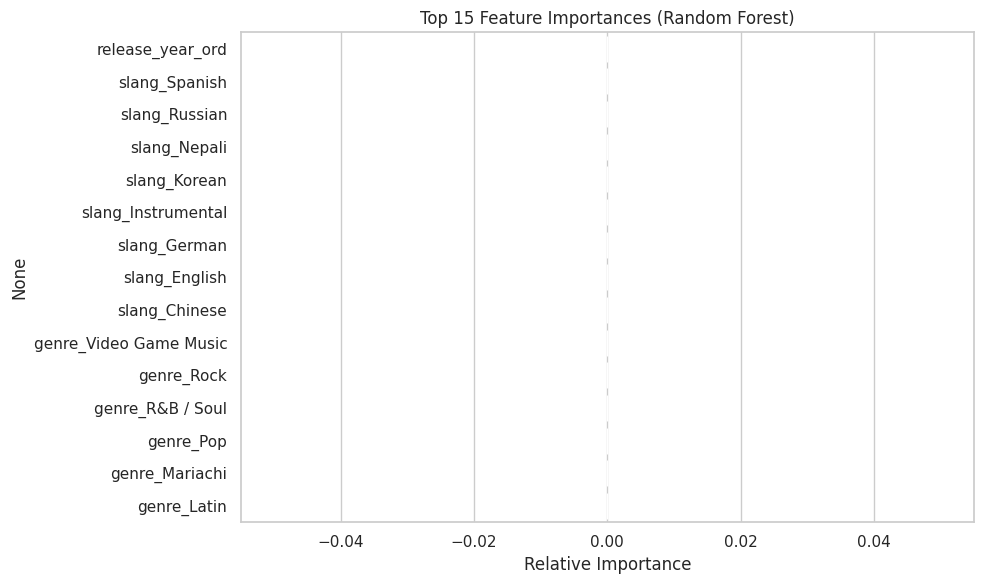

In [44]:
importances = best_rf.feature_importances_
indices = np.argsort(importances)[::-1][:15]

fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(x=importances[indices], y=X.columns[indices], ax=ax, palette='viridis')
ax.set_title('Top 15 Feature Importances (Random Forest)')
ax.set_xlabel('Relative Importance')
plt.tight_layout()
plt.show()

### Step 6: Sample Recommendations

In [45]:
def recommend_rf(user_id, model, top_k=5):
    user_interacted = set(df[df['user_id'] == user_id]['song'])
    candidate_songs = [s for s in unique_songs if s not in user_interacted]

    user_feat_vector = uf.loc[user_id].to_frame().T
    candidate_song_feats = sf.loc[candidate_songs].reset_index(drop=True)

    user_features_repeated = pd.concat([user_feat_vector]*len(candidate_songs), ignore_index=True)

    X_pred = pd.concat([user_features_repeated, candidate_song_feats], axis=1)

    probs = model.predict_proba(X_pred)[:, 1]

    top_indices = np.argsort(probs)[::-1][:top_k]
    top_songs = np.array(candidate_songs)[top_indices]

    res = pd.DataFrame({'song': top_songs, 'probability': probs[top_indices]})
    # Merge with original df to attach genre/artist info if desired for display
    metadata = df[['song', 'artist', 'genre']].drop_duplicates()
    return res.merge(metadata, on='song', how='left')

sample_user = df['user_id'].value_counts().index[0]
print(f"Recommendations for user: {sample_user}")
print(recommend_rf(sample_user, best_rf, top_k=5))

Recommendations for user: mariokart
             song  probability         artist          genre
0         Dashain      0.50326    Sugam Thapa            Pop
1       Who Knows      0.50326  Daniel Caesar     R&B / Soul
2           Lions      0.50326   Dire Straits           Rock
3      Fire Squad      0.50326         J.Cole  Hip Hop / Rap
4  CHAMPION SOUND      0.50326    Jordan Ward     R&B / Soul


### Step 7: Evaluation

In [46]:
# Predict labels and probabilities
y_pred = best_rf.predict(X_test)
y_prob = best_rf.predict_proba(X_test)[:, 1]

# Compute accuracy using mean comparison
accuracy = np.mean(y_pred == y_test)

print("--- Classification Metrics ---")
print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision_score(y_test, y_pred, zero_division=0):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred, zero_division=0):.4f}")
print(f"AUC-ROC:   {roc_auc_score(y_test, y_prob):.4f}\n")

print(classification_report(y_test, y_pred, zero_division=0))

--- Classification Metrics ---
Accuracy:  0.5000
Precision: 0.5000
Recall:    1.0000
AUC-ROC:   0.5000

              precision    recall  f1-score   support

           0       0.00      0.00      0.00        34
           1       0.50      1.00      0.67        34

    accuracy                           0.50        68
   macro avg       0.25      0.50      0.33        68
weighted avg       0.25      0.50      0.33        68

